<a href="https://colab.research.google.com/github/NatShed/MO_Attack/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2. Построение baseline-модели: от выбора парадигмы к метрикам качества

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, scikit-learn, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Научиться выбирать тип задачи, датасет, baseline-модель и метрики качества, а также сопоставлять структуру данных с соответствующей архитектурой или классическим алгоритмом.

## Результаты обучения
После выполнения работы вы должны уметь:
- различать парадигмы обучения (supervised / unsupervised / reinforcement learning);
- выбирать модель под тип данных и задачу;
- строить baseline для классификации или регрессии;
- выбирать и интерпретировать метрики качества (accuracy, precision, recall, F1, MSE, RMSE, R²);
- сравнивать несколько моделей и делать обоснованный вывод о лучшем baseline.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [22]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, pandas, matplotlib, sklearn.*

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,  # для классификации
    mean_squared_error, r2_score )

# TODO: зафиксируйте random_state для воспроизводимости
RANDOM_STATE = 42


## 1. Постановка задачи

**Задание:** выберите один датасет из списка (или согласуйте свой с преподавателем) и определите тип задачи.

Варианты:
- **fetch_20newsgroups** — многоклассовая классификация;
- **diabetes** — регрессия.
- **MNIST** — классификация изображений, простая MLP-модель.

**Вопрос для отчёта:** к какой парадигме обучения относится ваша задача (supervised / unsupervised / reinforcement learning) и почему? Какой тип задачи вы решаете — классификация или регрессия?


Я выбрала датасет - diabets (регрессия), даннаяя задача относится к обучению с учителем, т.к. у нас данные размеченные: есть признаки (возраст, пол, ИМТ, среднее артериальное давление и шесть различных сывороточных измерений крови (холестерин, триглицериды, гглюкоза и т.д.)) и целевая переменная (количественный показатель прогрессирования заболевания), между которыми модель будет учиться находить зависимость.Обучение без учителя здесь не подходит, нам не нужно искать структуру, как и обучение с плдкреплением (нет агента и среды). С данным датасетом решается задача регресси, потому что предсказанием является число, а не вероятность принадлежности к классу. Для оценки такой модели будут использовать метрики регрессии: MSE, RMSE, R².


## 2. Загрузка и разведочный анализ данных (EDA)

In [23]:
# TODO: загрузите выбранный датасет
from sklearn.datasets import load_diabetes

# Загружаем датасет diabetes сразу в виде pandas DataFrame
diabetes_data = load_diabetes(as_frame=True)
df = diabetes_data.frame

df.head() if df is not None else None


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [24]:
# TODO: проведите разведочный анализ данных
# - размер выборки (df.shape)
print("=== Размер выборки (строки, столбцы) ===")
print(df.shape)
print(f"В датасете {df.shape[0]} наблюдений и {df.shape[1]} признаков.\n")

# - типы признаков и целевая переменная (df.dtypes)
print("=== Типы данных ===")
print(df.dtypes)
print()

# - наличие пропусков (df.isna().sum())
print("=== Проверка на пропуски ===")
missing_values = df.isna().sum()
print(missing_values)
if missing_values.sum() == 0:
    print("Пропусков в данных нет.\n")
else:
    print(f"Обнаружены пропуски: {missing_values.sum()} значений.\n")

# - базовые статистики (df.describe())
print("=== Базовая статистика по всем данным ===")
print(df.describe().T) # .T (транспонирование) делает таблицу более читаемой

=== Размер выборки (строки, столбцы) ===
(442, 11)
В датасете 442 наблюдений и 11 признаков.

=== Типы данных ===
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

=== Проверка на пропуски ===
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64
Пропусков в данных нет.

=== Базовая статистика по всем данным ===
        count          mean        std        min        25%         50%  \
age     442.0 -2.511817e-19   0.047619  -0.107226  -0.037299    0.005383   
sex     442.0  1.230790e-17   0.047619  -0.044642  -0.044642   -0.044642   
bmi     442.0 -2.245564e-16   0.047619  -0.090275  -0.034229   -0.007284   
bp      442.0 -4.797570e-17   0.047619  -0.112399  -0.036656   -0.005670   
s1      442.0 -1.381499e-17   0.047619  -0.126781  -

**Вопрос для отчёта:** есть ли в данных пропуски, дисбаланс классов или сильно различающиеся масштабы признаков? Как это повлияет на выбор моделей и предобработки?

В данных количество значений для всез колоно одинакова - 442, пропусков данных нет, так что предобработка на заполнение пропусков не требуется.

Все входные признаки имеют среднее значение, близкое к нулю, и одинаковое стандартное отклонение (std). То есть данные уже представлены в едином виде, поэтому не требует нормализации и масштабирования.

Целевая переменная принимает значени от 25 до 346 - непрерывные числовые значения, что подтверждает задачу регрессии. Если смотреть на распредление, то среднее значение больше медианы, а максимальное значение находится от нее дальше, чем минимальное, получается, что у нас правосторонняя асимметрия, можем сделать вывод, что в данных есть пациенты с высоким показателем диабета, которые и вытягивают среднее значение вверх.

Как я уже писала выше, для оценки качества модели мы будем использовать метрики регресии:MSE, RMSE, R². Возможно, придется логарифмировать целевую переменную, чтобы данные стали более симметричные, чтобы линейная регрессия не подстраивалась под выбросы.


## 3. Предобработка данных

In [25]:
# TODO: разделите данные на train/test (train_test_split)
# TODO: при необходимости выполните масштабирование признаков (StandardScaler / MinMaxScaler)
# TODO: при необходимости выполните кодирование категориальных признаков (OneHotEncoder / get_dummies)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Определяем матрицу признаков (X) и целевую переменную (y)
X = df.drop(columns=['target'])
y = df['target']

# 2. Разделение данных на обучающую (80%) и тестовую (20%) выборки
# random_state=RANDOM_STATE гарантирует, что при каждом запуске данные разделятся одинаково
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Проверка размеров получившихся выборок
print("=== Размеры выборок после разделения ===")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")


=== Размеры выборок после разделения ===
X_train: (353, 10) | y_train: (353,)
X_test:  (89, 10) | y_test:  (89,)


## 4. Обучение моделей

**Задание:** обучите не менее **трёх** моделей из списка (минимум одну классическую и минимум одну альтернативную):
- логистическая / линейная регрессия;
- дерево решений;
- k-NN;
- простой MLP.


In [26]:
# Словарь для хранения результатов
results = []

# Модель 1  Линейная регрессия
# TODO: импортируйте и обучите первую модель
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append({
    "Модель": "Linear Regression",
    "MSE": mean_squared_error(y_test, y_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    "R2": r2_score(y_test, y_pred_lr)
})


In [27]:
# Модель 2 Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append({
    "Модель": "Random Forest",
    "MSE": mean_squared_error(y_test, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    "R2": r2_score(y_test, y_pred_rf)
})

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
# Модель 4 Градиентный бустинг
# n_estimators=100 — количество деревьев
# learning_rate=0.1 — вклад каждого дерева (шаг обучения)
# max_depth=3 — глубина каждого дерева (защита от переобучения)
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results.append({
    "Модель": "Gradient Boosting",
    "MSE": mean_squared_error(y_test, y_pred_gb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    "R2": r2_score(y_test, y_pred_gb)
})

## 5. Выбор и расчёт метрик качества

Для классификации используйте минимум **две** метрики из: accuracy, precision, recall, F1, confusion matrix.
Для регрессии используйте минимум **две** метрики из: MSE, RMSE, R².


In [29]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="R2", ascending=False).reset_index(drop=True)
print("=== Сравнение моделей ===")
print(df_results)

=== Сравнение моделей ===
              Модель          MSE       RMSE        R2
0  Gradient Boosting  2898.436673  53.837131  0.452934
1  Linear Regression  2900.193628  53.853446  0.452603
2      Random Forest  2952.010589  54.332408  0.442823


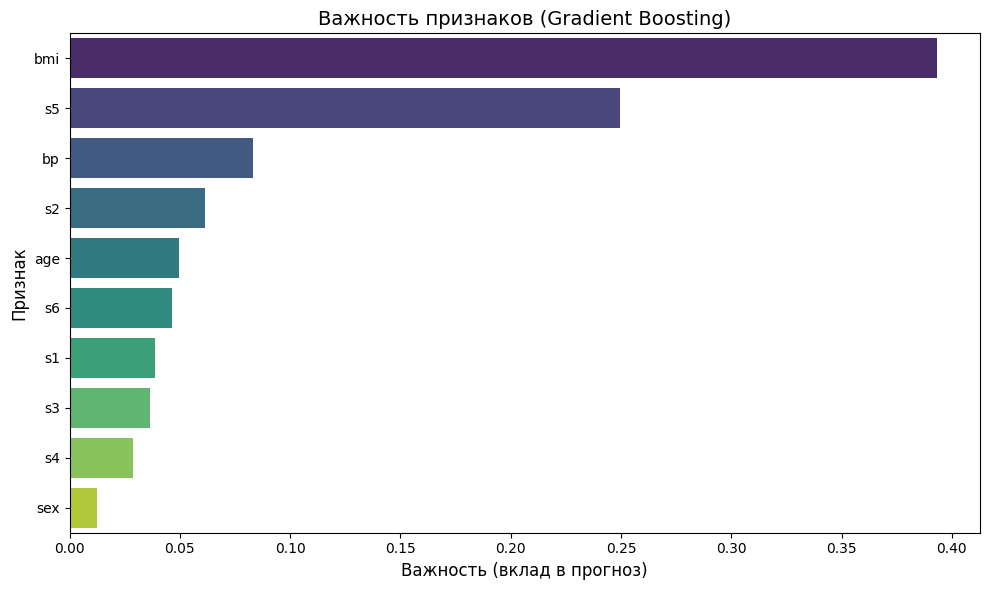

In [30]:
# TODO: постройте минимум одну визуализацию
import seaborn as sns

# --- Визуализация 1: Важность признаков (Feature Importance) ---
# Используем лучшую модель — Gradient Boosting
importances = gb.feature_importances_
feature_names = X.columns

# Создаем DataFrame для удобной сортировки
feature_imp_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances
}).sort_values(by='Важность', ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
sns.barplot(x='Важность', y='Признак', data=feature_imp_df,  hue='Признак', palette='viridis')
plt.title('Важность признаков (Gradient Boosting)', fontsize=14)
plt.xlabel('Важность (вклад в прогноз)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()


Краткий вывод: наибольший вклад в прогносс вносят ИМТ и уровень липидов в крови. При этом модель практически не использует пол для предсказания.

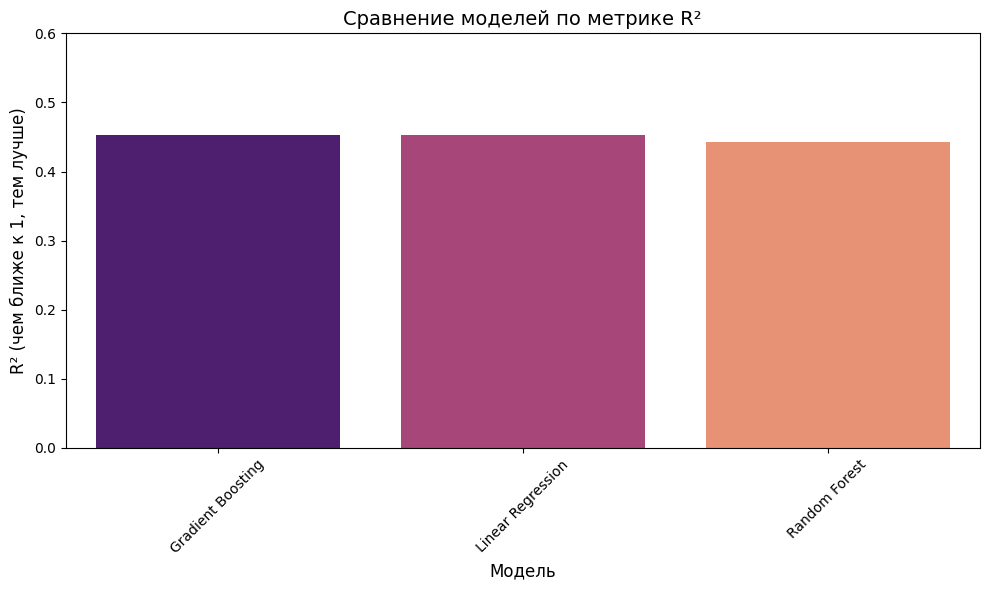

In [31]:
# --- Визуализация 2: Сравнение метрик моделей ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Модель', y='R2', data=df_results, hue='Модель', palette='magma')
plt.title('Сравнение моделей по метрике R²', fontsize=14)
plt.xlabel('Модель', fontsize=12)
plt.ylabel('R² (чем ближе к 1, тем лучше)', fontsize=12)
plt.ylim(0, 0.6)  # Ограничиваем ось Y, чтобы разница была заметнее
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** почему вы выбрали именно эти метрики? В каких случаях accuracy может вводить в заблуждение (например, при дисбалансе классов)?

MSE (Mean Squared Error)- среднеквадратичная ошибка (берется разница между реальным и предсказанным значения, возводится в квадрат и усредняется по всем объектам), многие алгоритмы (в том числе и Gradient Boosting) используют ее как функцию потерь. RMSE (Root Mean Squared Error) измеряется в тех же единицах, что и целевая перменная. Коэффициент детерминации показывает, какую долю общего разброса целевой переменной смогла предопределить наша модель, что позволяет нам сравнить модели.


Accuracy (Доля правильных ответов) - метрика классификациии нам не подходи. Но если говрить о ее недостатке, то она ошибается при следующих случаях: дисбаланс классов, разная цена ошибки (в медицинских показаниях - пропумк болезни опаснее ложного диашназа), мультиклассовые задачи с перекосом (если один класс доминирует, метрика будет высокой за счет него, игнорируя качество предсказания редких классов)



## 6. Анализ ошибок

In [32]:
# TODO: проанализируйте ошибки лучшей модели
# - какие объекты классифицируются неверно?
# - есть ли систематическая ошибка (например, путаница конкретных двух классов)?


In [33]:
# 1. Собираем предсказания лучшей модели (Gradient Boosting)
y_pred_best = gb.predict(X_test)

# 2. Создаем DataFrame для анализа ошибок
error_df = pd.DataFrame({
    'Реальное значение': y_test,
    'Предсказание': y_pred_best,
    'Ошибка (Residual)': y_test - y_pred_best,
    'Абсолютная ошибка': np.abs(y_test - y_pred_best)
})

# 3. Находим ТОП-5 объектов с самой большой ошибкой
print("=== ТОП-5 объектов с наибольшей ошибкой ===")
top_errors = error_df.sort_values(by='Абсолютная ошибка', ascending=False).head(5)
display(top_errors)

=== ТОП-5 объектов с наибольшей ошибкой ===


,Реальное значение,Предсказание,Ошибка (Residual),Абсолютная ошибка
56,52.0,183.736157,-131.736157,131.736157
211,70.0,190.524837,-120.524837,120.524837
9,310.0,192.351405,117.648595,117.648595
423,91.0,205.970640,-114.970640,114.970640
209,77.0,179.475728,-102.475728,102.475728


Наибольшие ошибки модель совершает на объектах, которое наиболее отдалены от среднего занчения (152) (выбросы). Таких пациентов мало в обучающей выборке, модель не смогла обнаржуить закономерность.


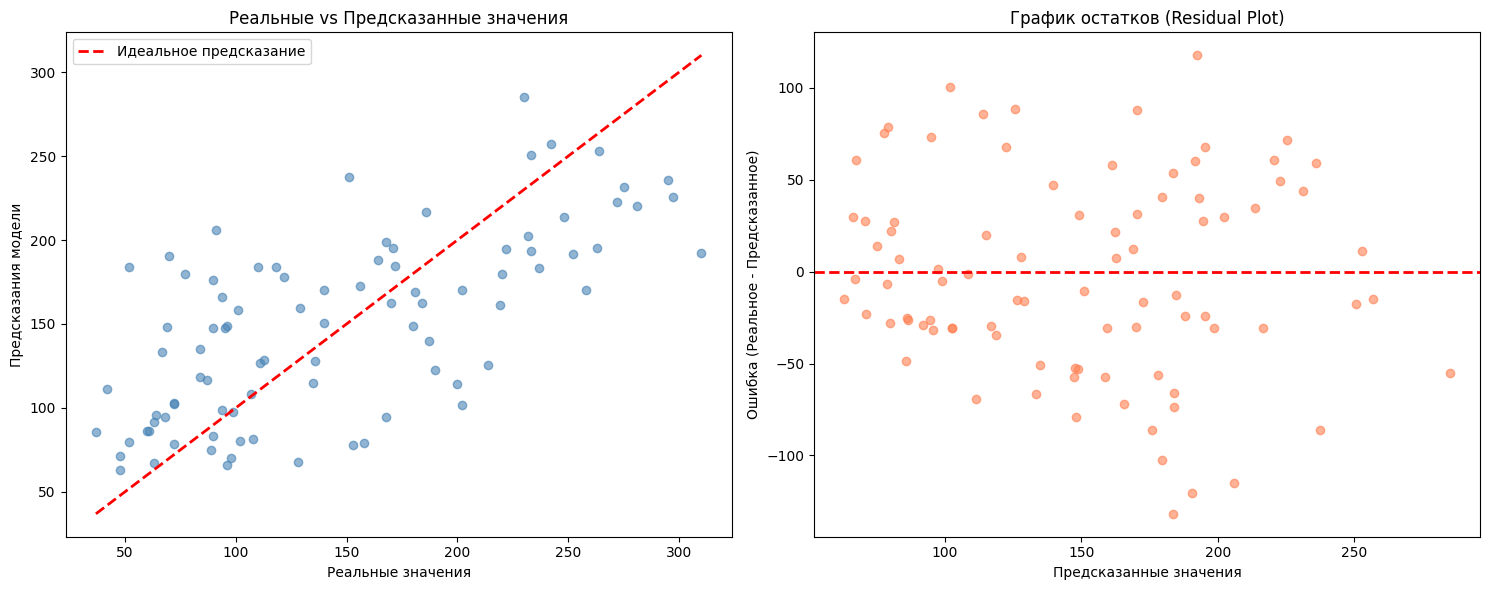

In [34]:
# 4. Визуализация ошибок
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Реальные vs Предсказанные значения
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
axes[0].set_xlabel('Реальные значения')
axes[0].set_ylabel('Предсказания модели')
axes[0].set_title('Реальные vs Предсказанные значения')
axes[0].legend()

# График 2: График остатков (Residual Plot)
axes[1].scatter(y_pred_best, error_df['Ошибка (Residual)'], alpha=0.6, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Ошибка (Реальное - Предсказанное)')
axes[1].set_title('График остатков (Residual Plot)')

plt.tight_layout()
plt.show()


In [35]:
# 5. Проверка на систематическую ошибку (средняя ошибка)
print(f"\nСредняя ошибка (Mean Residual): {error_df['Ошибка (Residual)'].mean():.2f}")
print(f"Стандартное отклонение ошибки: {error_df['Ошибка (Residual)'].std():.2f}")


Средняя ошибка (Mean Residual): -3.06
Стандартное отклонение ошибки: 54.05


По графикам видно, что у нас есть систематическая ошибка. Для пациентов с низкими предсказанными значениями модель склонна немного завышать прогноз, а для пациентов с высокими значениями — занижать. Это подтверждается тем, что средняя ошибка (Mean Residual)отклоняется от нуля. Такое поведение типично для линейных и древовидных моделей на данных с правосторонней асимметрией. При это ее значение очень близко к нулю, серьезного систематического смещения нет, модель не склонная постоянно завышать или занижать прогнозы для ВСЕХ пациентов. При этом для конкретного пациента может ошибиться очень сильно (что ожидаемо, учитывая коэффициент детерминации = 0,45).

## 7. Сравнение моделей и вывод

**Вопрос для отчёта:** какая модель показала лучший результат по выбранным метрикам? Согласуется ли это с ожиданиями, учитывая структуру данных (линейность, размер выборки, число признаков)? Какую модель вы бы выбрали в качестве baseline и почему?

Результаты трех моделе примерно одинаковые, но все-таки лучший результат показал Gradient Boosting: R² = 0.4529 (наибольший), RMSE = 53.84 (наименьший). Но разница с линейной регрессией незначительна и составляет всего 0.0003. Результаты согласаются с ожиданиями: одинаковы результат первых двух моделей доказывает, что зависимость между признакми и целевой переменной преимущественно линейна. Random Forest склонен к переобучению и для него размер выборки довольно мал, поэтому он уступил простой линейной модели. При этом результат 0,45 для  медицинских данных нормален. 55% разброса, который не может объяснить модель, может быть случайным шумом или факторами, которые не были учитаны в данном датасете (генетика, образ жизни, питание и т.п.). Так же коэффициент детерминации ограничивают выбросы. В качестве baseline я бы выбрала линейную регрессию, несмотря на то, что градиентный бустинг формально показал лучший результат, разница у них незначительна. Получается, что у градиентный бустинг не дает преимуществ, но увеличивает вычислительную сложность и снижает уитерпретируем. Линейная регрессия быстрее и более устойчива на небольшой выборке.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже

### С1. Кластеризация как альтернативный взгляд на данные
Примените unsupervised-подход (например, KMeans) к тем же признакам без использования целевой переменной. Сравните полученные кластеры с реальными классами/значениями целевой переменной. Обсудите: совпадает ли структура кластеров с реальной разметкой? Что это говорит о структуре данных?

### С2. Классический baseline vs простой MLP
Обучите простую нейросеть (MLPClassifier/MLPRegressor из sklearn, либо небольшую сеть на PyTorch) на тех же признаках и сравните её с лучшей классической моделью по тем же метрикам. Объясните, почему нейросеть выигрывает/проигрывает при данном объёме данных и числе признаков.

### С3. Устойчивость вывода о «лучшей» модели к выбору метрики
Постройте искусственный дисбаланс классов (например, undersampling одного класса) и пересчитайте метрики для всех моделей. Проверьте: меняется ли ранжирование моделей при использовании accuracy против F1/recall? Сделайте вывод о том, почему выбор метрики критичен при дисбалансе.

### С4. Кросс-валидация и доверительный интервал качества
Замените единичный train/test split на k-fold кросс-валидацию (cross_val_score) для всех моделей. Постройте boxplot распределения метрики по фолдам. Обсудите, насколько стабильны результаты моделей.


=== Статистика целевой переменной по кластерам ===
         count        mean        std   min    max
Кластер                                           
0          125  197.392000  67.686051  63.0  332.0
1          159  160.440252  79.275963  42.0  346.0
2          158  107.968354  55.565125  25.0  302.0

Silhouette Score: 0.1535
(Значения близко к 1 — кластеры хорошо разделены, к 0 — плохо)


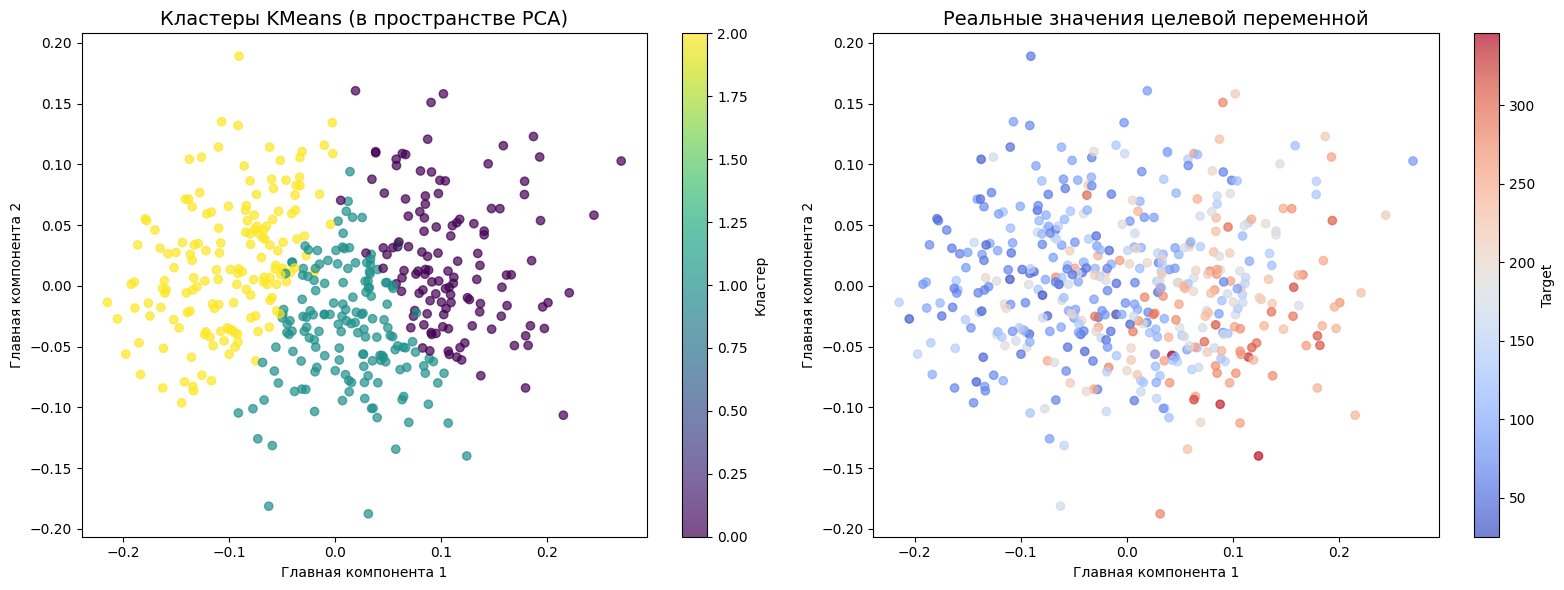

In [36]:
# ============================================================
# ЗАДАНИЕ С1: Кластеризация как альтернативный взгляд на данные
# ============================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Берем ТОЛЬКО признаки (X), без целевой переменной
X_cluster = X.copy()

# 2. Обучаем KMeans. Попробуем 3 кластера (гипотеза: низкий/средний/высокий риск)
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# 3. Смотрим, как распределилась целевая переменная по кластерам
cluster_analysis = pd.DataFrame({
    'Кластер': clusters,
    'Target': y.values
})
print("=== Статистика целевой переменной по кластерам ===")
print(cluster_analysis.groupby('Кластер')['Target'].agg(['count', 'mean', 'std', 'min', 'max']))

# 4. Метрика качества кластеризации (Silhouette Score)
sil_score = silhouette_score(X_cluster, clusters)
print(f"\nSilhouette Score: {sil_score:.4f}")
print("(Значения близко к 1 — кластеры хорошо разделены, к 0 — плохо)")

# 5. Визуализация: PCA для снижения размерности до 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Кластеры в пространстве PCA
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
axes[0].set_title('Кластеры KMeans (в пространстве PCA)', fontsize=14)
axes[0].set_xlabel('Главная компонента 1')
axes[0].set_ylabel('Главная компонента 2')
plt.colorbar(scatter1, ax=axes[0], label='Кластер')

# График 2: Реальные значения target в том же пространстве
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
axes[1].set_title('Реальные значения целевой переменной', fontsize=14)
axes[1].set_xlabel('Главная компонента 1')
axes[1].set_ylabel('Главная компонента 2')
plt.colorbar(scatter2, ax=axes[1], label='Target')

plt.tight_layout()
plt.show()

Кластеры не совпадают с реальной структурой целевой переменной, датасет представляет собой единой непрерывное простарнство, в котором целевая переменная меняет плавно, а не скачками между группами. Низкий коэффициент Silhouette Score также показывает, что объекты плохо делятся на кластеры. И это объясняет, почему линейные модели работают так же хорошо, как сложные нелинейные.

Linear Regression         | R² по фолдам: [0.453 0.573 0.391 0.584 0.391] | Среднее: 0.4785 ± 0.0850
Random Forest             | R² по фолдам: [0.428 0.528 0.279 0.481 0.43 ] | Среднее: 0.4294 ± 0.0836
Gradient Boosting         | R² по фолдам: [0.452 0.48  0.245 0.48  0.427] | Среднее: 0.4169 ± 0.0884


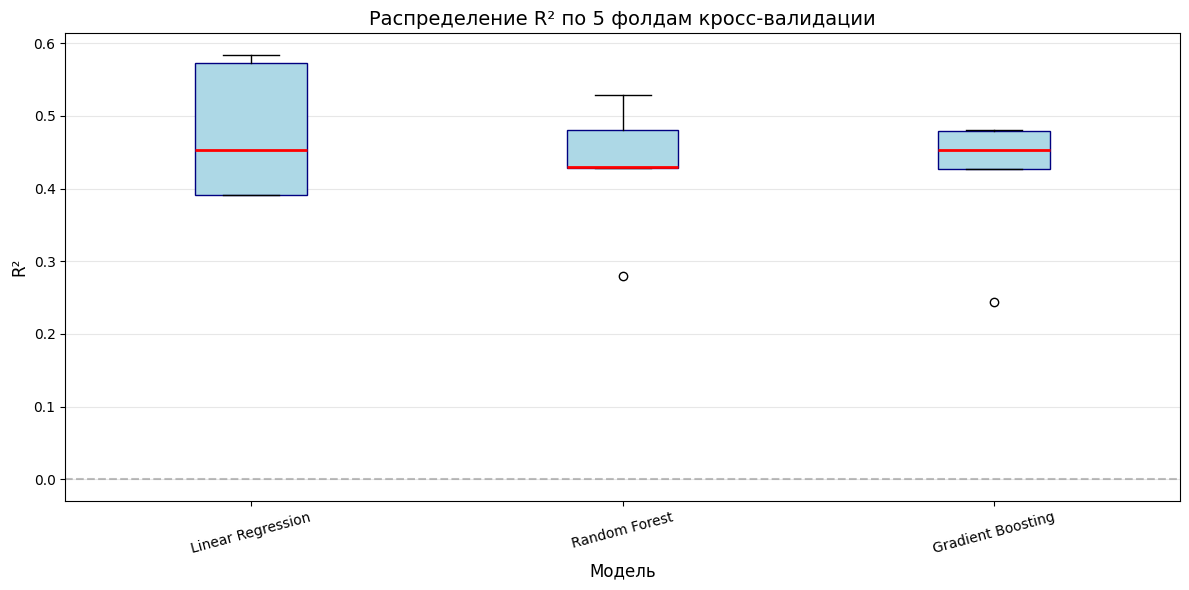


=== Итоговая таблица кросс-валидации ===


,Модель,Среднее R²,Стд. отклонение,Минимум,Максимум
0,Linear Regression,0.478470,0.084967,0.390812,0.584289
1,Random Forest,0.429359,0.083592,0.279244,0.528018
2,Gradient Boosting,0.416866,0.088370,0.244601,0.480370


In [37]:
# ============================================================
# ЗАДАНИЕ С4: Кросс-валидация и доверительный интервал качества
# ============================================================
from sklearn.model_selection import cross_val_score, KFold

# 1. Настраиваем 5-фолдовую кросс-валидацию
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 2. Список моделей для проверки
models_cv = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
}

# 3. Считаем R² по фолдам для каждой модели
cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    cv_results[name] = scores
    print(f"{name:25s} | R² по фолдам: {np.round(scores, 3)} | Среднее: {scores.mean():.4f} ± {scores.std():.4f}")

# 4. Визуализация — Boxplot распределения метрик
plt.figure(figsize=(12, 6))
plt.boxplot(cv_results.values(), tick_labels=list(cv_results.keys()), patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Распределение R² по 5 фолдам кросс-валидации', fontsize=14)
plt.ylabel('R²', fontsize=12)
plt.xlabel('Модель', fontsize=12)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Вывод со средними значениями и диапазоном
print("\n=== Итоговая таблица кросс-валидации ===")
summary = pd.DataFrame({
    'Модель': list(cv_results.keys()),
    'Среднее R²': [v.mean() for v in cv_results.values()],
    'Стд. отклонение': [v.std() for v in cv_results.values()],
    'Минимум': [v.min() for v in cv_results.values()],
    'Максимум': [v.max() for v in cv_results.values()]
}).sort_values(by='Среднее R²', ascending=False).reset_index(drop=True)
display(summary)

Результаты кросс-валидации подтверждают, что линейная регрессия является самой лучшей для данной задачи. Random Forest, Gradient Boosting на такой небольшой выборке склонны к переобучению.

Если анализировать боксплот, то можно заметить, что линейная регрессия нестабильно, но катастрофических провалов нет, много шумов (0,39), но все-таки модель рабочая. Случайный лес работает стабильно, но на одном фолде провалилась - результат переобучения, модель хорошо запомнила большиснтво примеров, но дала плохие результаты, когда столкнулась с незнакомой комбинацией. Градиентный бустинг имеет самый узкий ящик, но при этом приошибки коэффициент детерминации провалился до 0,25. Получается, у линейной регрессии отсутствуют
сильные провалы, что подтверждает ее предпочтительность.

---



## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Минимум 3 модели, минимум 2 метрики, минимум 1 визуализация.
